In [1]:
import numpy as np # type: ignore
import MDAnalysis as mda # type: ignore
import matplotlib.pyplot as plt # type: ignore

from MDAnalysis.analysis import pca as mda_pca # type: ignore
from MDAnalysis.analysis import align # type: ignore
from sklearn.decomposition import PCA # type: ignore

%matplotlib inline
%load_ext autoreload
%autoreload 2

/media/users/debarshi/scratch/mambaforge/envs/md/lib/python3.11/site-packages/Bio/Application/__init__.py:40: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [2]:
def write_projections(
    eigvec,
    reduced_coords,
    atom_names,
    starting_traj,
    n_atoms,
    n_frames,
    projected_traj_output,
):
    """
    Example usage:
    write_projections(eigvec[vec_proj,:],reduced_coords[:,vec_proj],atom_names,traj[0].positions,n_atoms,n_frames,"project_"+str(vec_proj)+".xyz")
    eigvec --> relevant component of eigenvector (shape of eigvecs returned by SKL: (n_components, n_features))
    reduced_coords --> relevant component of reduced coordinates (original data is projected on the PCs) (shape of reduced coords returned by SKL: (n_frames, n_components))
    atom_names --> name of the atoms for the XYZ file
    starting_traj --> the positions to which the eigenvector components are added (can be mean or starting positions)
    n_atoms --> number of atoms
    n_frames --> number of frames
    projected_traj_output --> output file name
    """
    #!# reshape eigenvector component array into something same as the atom positions array
    eigvecs_atom_components = eigvec.reshape(n_atoms, 3)
    ff = open(projected_traj_output, "w")
    for ii in range(0, n_frames, 10):
        #!# choose the reduced coordinated value for the relevant frame (shape of reduced coords returned by SKL: (n_frames, n_components))
        rc = reduced_coords[ii]
        ff.write(str(n_atoms) + "\n")
        ff.write("\n")
        for jj in range(n_atoms):
            atom = str(atom_names[jj]).split("-")[-1]
            atom = list(atom)[0]
            #!# to the starting/mean position of each atom, add the relevant projection of the reduced coordinates on the relevant eigenvector
            #!# this gives us the changee effected due to the eigenvector
            posi = starting_traj[jj, :] + eigvecs_atom_components[jj, :] * rc
            ff.write(
                str(atom)
                + "  "
                + str(posi[0])
                + "   "
                + str(posi[1])
                + "   "
                + str(posi[2])
                + "\n"
            )
    ff.close()

 # S1 - Essential Dynamics

In [3]:
## Load the trajectories
uni_og_s1 = mda.Universe("./traj_data/traj_S1.xyz")

## Get the first frame so we can align to the first frame
uni_og_s1.trajectory[0]

with mda.Writer("./traj_data/first_frame_s1.xyz", uni_og_s1.atoms.n_atoms) as W:  # type: ignore
    W.write(uni_og_s1.atoms)

first_frame_uni_s1 = mda.Universe("./traj_data/first_frame_s1.xyz")

In [4]:
! head -n5 ./traj_data/first_frame_s1.xyz

47
frame 0 | Written by MDAnalysis XYZWriter (release 2.7.0)
       C     3.85694   -2.77487    2.29020
       C     2.57368   -3.31612    2.33960
       C     1.48431   -2.59417    1.76414


In [5]:
## Align the trajectory to the first frame to remove rotations and translations

aligned_traj_s1 = align.AlignTraj(
    mobile=uni_og_s1,
    reference=first_frame_uni_s1,
    select="all",
    strict=True,
    verbose=True,
    prefix="./traj_data/rmsfit_",
)
aligned_traj_s1.run()

  0%|          | 0/234664 [00:00<?, ?it/s]

/media/users/debarshi/scratch/mambaforge/envs/md/lib/python3.11/site-packages/MDAnalysis/analysis/base.py:447: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[i] = ts.time


In [6]:
## Load the aligned trajectories

uni_s1 = mda.Universe("./traj_data/rmsfit_traj_S1.xyz")
traj_s1 = uni_s1.trajectory.trajectory

In [7]:
n_atoms = traj_s1.n_atoms
n_frames = traj_s1.n_frames
atom_names = uni_og_s1.atoms.names  # type: ignore
frame_start = 0
frame_end = n_frames

atom_pos_s1 = np.zeros((n_frames, 3 * n_atoms))
atom_mean_pos_s1 = np.zeros((n_atoms, 3))

## Write the atom positions into a flattened array to do PCA
for i, frame in enumerate(traj_s1[frame_start:frame_end:1]):
    xyz = frame.positions.flatten()
    atom_pos_s1[i, :] = xyz
    atom_mean_pos_s1 += frame.positions

atom_mean_pos_s1 /= frame_end - frame_start

print(atom_pos_s1.shape)
print(atom_mean_pos_s1.shape)

(234664, 141)
(47, 3)


In [8]:
## Do PCA and get the eigenvalues, eigenvectors, and reduced coordinates

# n_components: number of Principal Components (adjust by pca = PCA(n_components=3))
# n_features: number of features in the covariance matrix (number of atom positions == 3 * n_atoms)
# n_samples: number of points in the dataset (number of frames/points)

pca_s1 = PCA()

## Projection of X in the first principal components: (n_samples, n_components)
reduced_coords_s1 = pca_s1.fit_transform(atom_pos_s1)

## (n_components, n_features)
eigvecs_s1 = pca_s1.components_

## (n_components,)
eigvals_s1 = pca_s1.explained_variance_

## (n_components,)
expl_var_s1 = pca_s1.explained_variance_ratio_

Explained Variance array shape: (141,)
Eigenvalue array shape: (141,)
Eigenvector array shape: (141, 141)


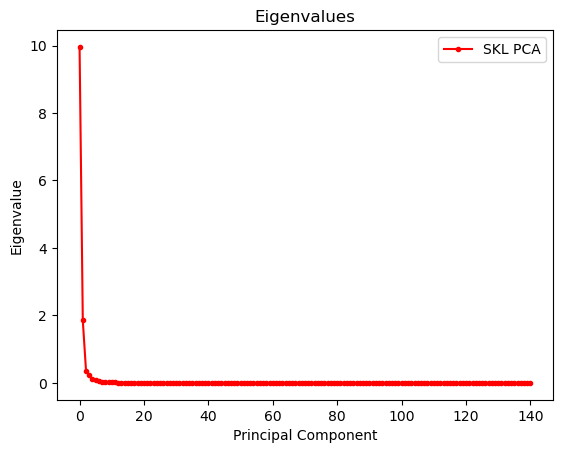

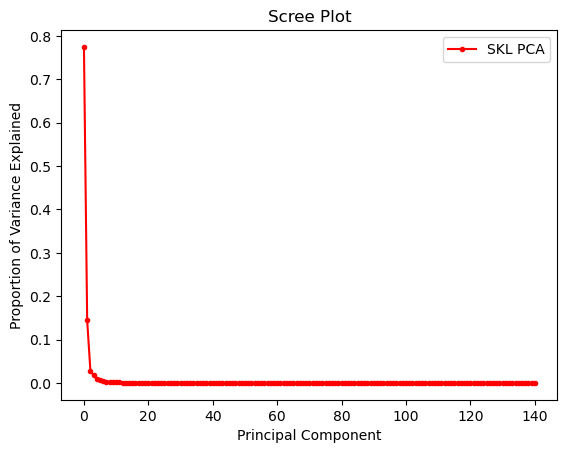

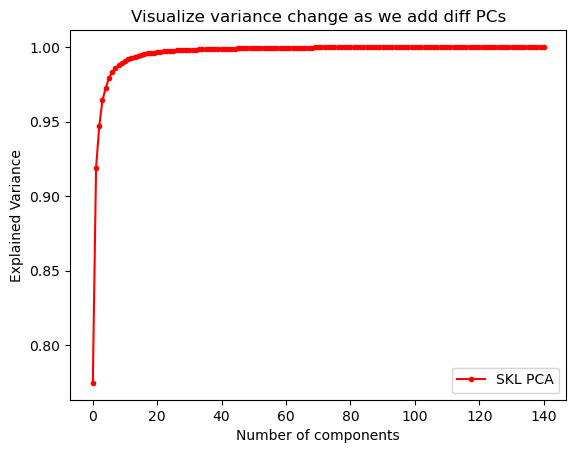

In [9]:
## Plot the Eigenvalues

print("Explained Variance array shape:", expl_var_s1.shape)
print("Eigenvalue array shape:", eigvals_s1.shape)
print("Eigenvector array shape:", eigvecs_s1.shape)

plt.title("Eigenvalues")
plt.plot(eigvals_s1, "r.-", label="SKL PCA")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.legend()
plt.show()

plt.title("Scree Plot")
plt.plot(expl_var_s1, "r.-", label="SKL PCA")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.legend()
plt.show()

plt.title("Visualize variance change as we add diff PCs")
plt.ylabel("Explained Variance")
plt.xlabel("Number of components")
plt.plot(np.cumsum(expl_var_s1), "r.-", label="SKL PCA")
plt.legend()
plt.show()

## Trajectory corresponding to motion along each PC/eigenvector

In [10]:
for ii in range(0, 10):
    print("WRITING PROJECTION " + str(ii))
    vec_proj = ii
    write_projections(
        eigvecs_s1[vec_proj, :],
        reduced_coords_s1[:, vec_proj],
        atom_names,
        traj_s1[0].positions,
        n_atoms,
        n_frames,
        "./PCA_projections/S1_project_" + str(vec_proj) + ".xyz",
    )
    write_projections(
        eigvecs_s1[vec_proj, :],
        reduced_coords_s1[:, vec_proj],
        atom_names,
        atom_mean_pos_s1,
        n_atoms,
        n_frames,
        "./PCA_projections/S1_mean_project_" + str(vec_proj) + ".xyz",
    )

WRITING PROJECTION 0
WRITING PROJECTION 1
WRITING PROJECTION 2
WRITING PROJECTION 3
WRITING PROJECTION 4
WRITING PROJECTION 5
WRITING PROJECTION 6
WRITING PROJECTION 7
WRITING PROJECTION 8
WRITING PROJECTION 9


## Observe PC projections on each frame

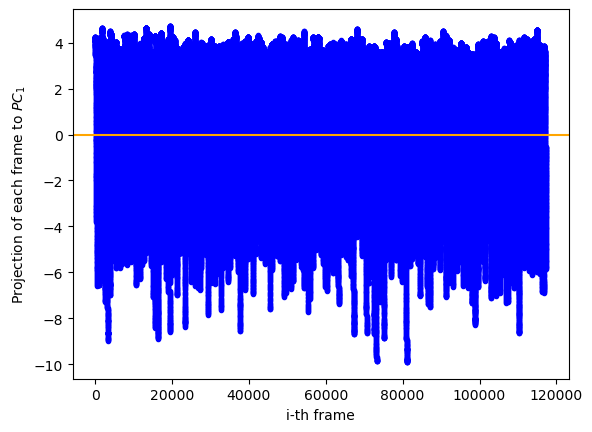

In [11]:
## this gives us the same thing as plotting reduced_coords[:,0] which is the reduced coord corresponding to the first PC

pos_projected_pc1 = (atom_pos_s1 - np.average(atom_pos_s1, axis=0)) @ eigvecs_s1[0, :]

plt.plot(pos_projected_pc1[::2], "b.")
plt.axhline(np.mean(pos_projected_pc1), color="orange")
plt.xlabel("i-th frame")
plt.ylabel("Projection of each frame to $PC_1$")
plt.show()

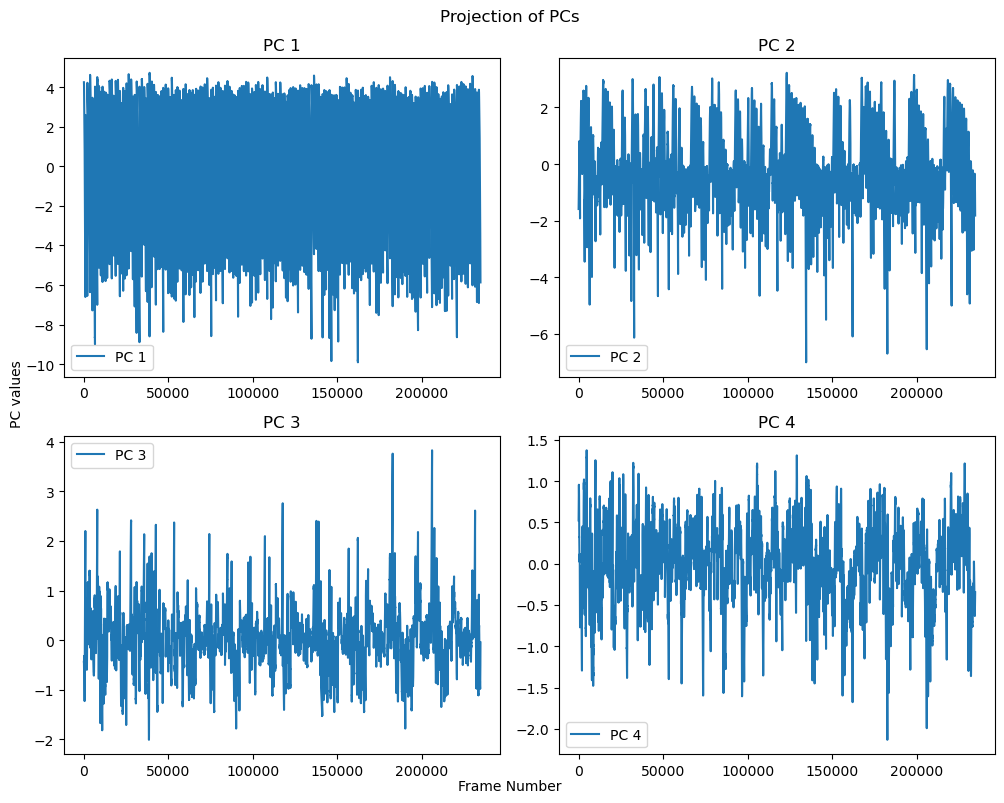

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].plot(reduced_coords_s1[:, 0], label="PC 1")
axes[0, 0].set_title("PC 1")
axes[0, 0].legend()

axes[0, 1].plot(reduced_coords_s1[:, 1], label="PC 2")
axes[0, 1].set_title("PC 2")
axes[0, 1].legend()

axes[1, 0].plot(reduced_coords_s1[:, 2], label="PC 3")
axes[1, 0].set_title("PC 3")
axes[1, 0].legend()

axes[1, 1].plot(reduced_coords_s1[:, 3], label="PC 4")
axes[1, 1].set_title("PC 4")
axes[1, 1].legend()

fig.suptitle("Projection of PCs", fontsize=12)
fig.text(
    0.5, 0.0, "Frame Number", ha="center", va="bottom"
)  # Adjust position as needed
fig.text(0.0, 0.5, "PC values", va="center", rotation="vertical")


plt.tight_layout()
plt.show()

## Compare SKLearn PCA to MDAnalysis PCA

In [13]:
test_pc = mda_pca.PCA(
    uni_s1, select="all", align=True, mean=None, n_components=None
).run()

/media/users/debarshi/scratch/mambaforge/envs/md/lib/python3.11/site-packages/MDAnalysis/analysis/base.py:447: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[i] = ts.time


(141, 141)
PC1: 9.95838
PC2: 1.85025


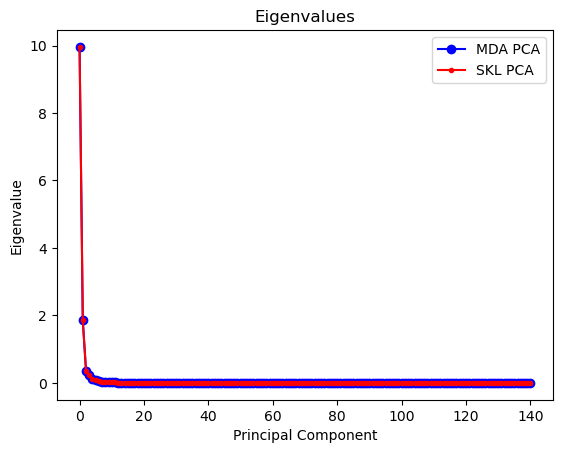

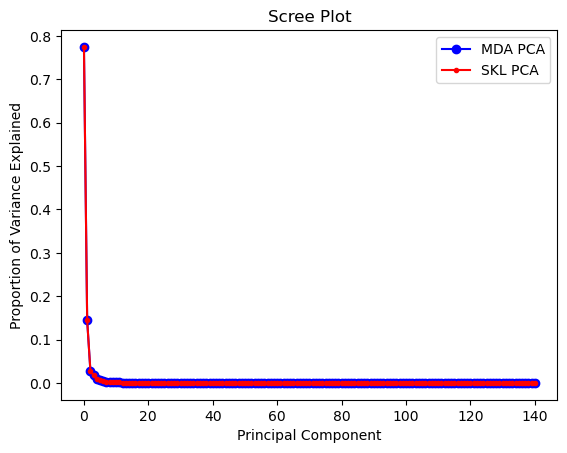

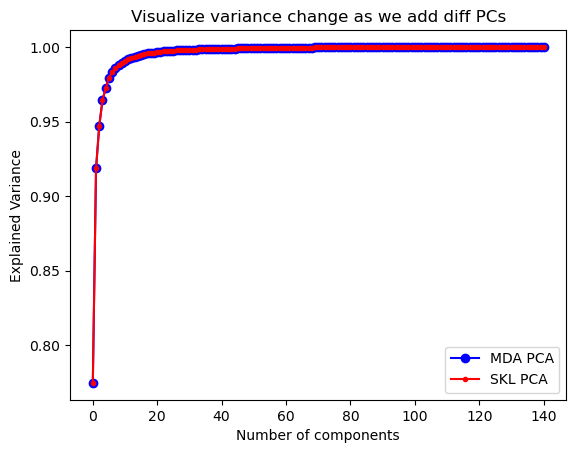

In [14]:
print(test_pc.results.p_components.shape)
print(f"PC1: {test_pc.results.variance[0]:.5f}")
print(f"PC2: {test_pc.results.variance[1]:.5f}")

plt.title("Eigenvalues")
plt.plot(test_pc.results.variance, "bo-", label="MDA PCA")
plt.plot(eigvals_s1, "r.-", label="SKL PCA")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.legend()
plt.show()

plt.title("Scree Plot")
plt.plot(
    test_pc.results.variance / np.sum(test_pc.results.variance), "bo-", label="MDA PCA"
)
plt.plot(expl_var_s1, "r.-", label="SKL PCA")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.legend()
plt.show()

plt.title("Visualize variance change as we add diff PCs")
plt.ylabel("Explained Variance")
plt.xlabel("Number of components")
plt.plot(test_pc.results.cumulated_variance, "bo-", label="MDA PCA")
plt.plot(np.cumsum(expl_var_s1), "r.-", label="SKL PCA")
plt.legend()
plt.show()

 # S0 - Essential Dynamics

In [15]:
## Load the trajectories
uni_og_s0 = mda.Universe("./traj_data/traj_S0.xyz")

## Get the first frame so we can align to the first frame
uni_og_s0.trajectory[0]

with mda.Writer("./traj_data/first_frame_s0.xyz", uni_og_s0.atoms.n_atoms) as W:  # type: ignore
    W.write(uni_og_s0.atoms)

first_frame_uni_s0 = mda.Universe("./traj_data/first_frame_s0.xyz")

In [16]:
! head -n5 ./traj_data/first_frame_s0.xyz

47
frame 0 | Written by MDAnalysis XYZWriter (release 2.7.0)
       C     4.21986   -1.14551   -1.10090
       C     3.46730   -1.99407   -0.18399
       C     2.17764   -1.65682    0.18172


In [17]:
## Align the trajectory to the first frame to remove rotations and translations

aligned_traj_s0 = align.AlignTraj(
    mobile=uni_og_s0,
    reference=first_frame_uni_s0,
    select="all",
    strict=True,
    verbose=True,
    prefix="./traj_data/rmsfit_",
)
aligned_traj_s0.run()

  0%|          | 0/163190 [00:00<?, ?it/s]

In [18]:
## Load the aligned trajectories

uni_s0 = mda.Universe("./traj_data/rmsfit_traj_S0.xyz")
traj_s0 = uni_s0.trajectory.trajectory

In [19]:
n_atoms = traj_s0.n_atoms
n_frames = traj_s0.n_frames
atom_names = uni_og_s0.atoms.names  # type: ignore
frame_start = 0
frame_end = n_frames

atom_pos_s0 = np.zeros((n_frames, 3 * n_atoms))
atom_mean_pos_s0 = np.zeros((n_atoms, 3))

## Write the atom positions into a flattened array to do PCA
for i, frame in enumerate(traj_s0[frame_start:frame_end:1]):
    xyz = frame.positions.flatten()
    atom_pos_s0[i, :] = xyz
    atom_mean_pos_s0 += frame.positions

atom_mean_pos_s0 /= frame_end - frame_start

print(atom_pos_s0.shape)
print(atom_mean_pos_s0.shape)

(163190, 141)
(47, 3)


In [20]:
## Do PCA and get the eigenvalues, eigenvectors, and reduced coordinates

# n_components: number of Principal Components (adjust by pca = PCA(n_components=3))
# n_features: number of features in the covariance matrix (number of atom positions == 3 * n_atoms)
# n_samples: number of points in the dataset (number of frames/points)

pca_s0 = PCA()

## Projection of X in the first principal components: (n_samples, n_components)
reduced_coords_s0 = pca_s0.fit_transform(atom_pos_s0)

## (n_components, n_features)
eigvecs_s0 = pca_s0.components_

## (n_components,)
eigvals_s0 = pca_s0.explained_variance_

## (n_components,)
expl_var_s0 = pca_s0.explained_variance_ratio_

Explained Variance array shape: (141,)
Eigenvalue array shape: (141,)
Eigenvector array shape: (141, 141)


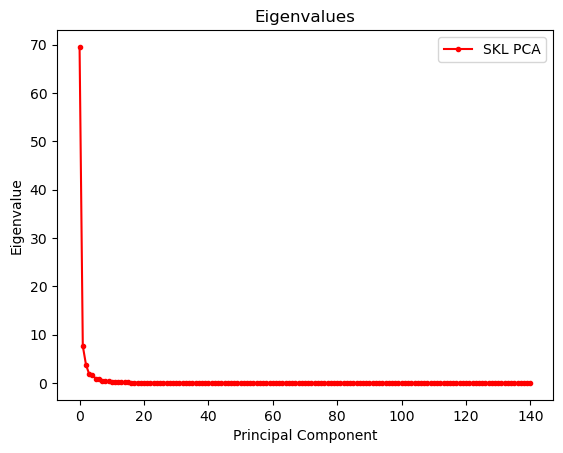

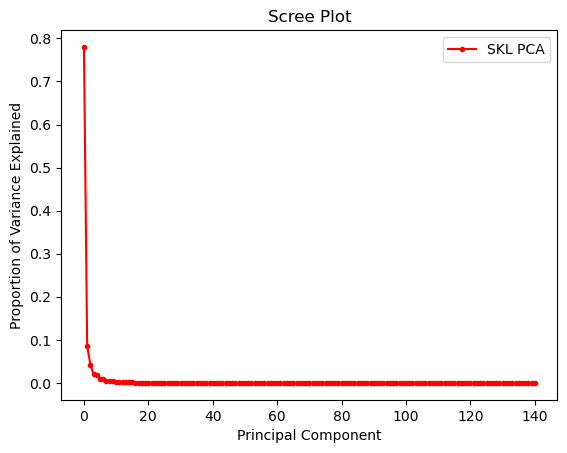

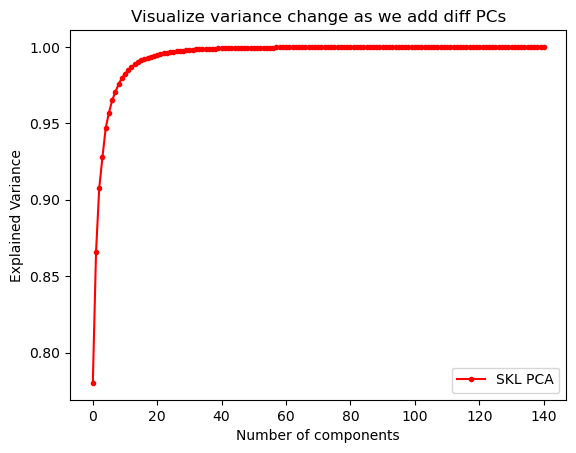

In [21]:
## Plot the Eigenvalues

print("Explained Variance array shape:", expl_var_s0.shape)
print("Eigenvalue array shape:", eigvals_s0.shape)
print("Eigenvector array shape:", eigvecs_s0.shape)

plt.title("Eigenvalues")
plt.plot(eigvals_s0, "r.-", label="SKL PCA")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.legend()
plt.show()

plt.title("Scree Plot")
plt.plot(expl_var_s0, "r.-", label="SKL PCA")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.legend()
plt.show()

plt.title("Visualize variance change as we add diff PCs")
plt.ylabel("Explained Variance")
plt.xlabel("Number of components")
plt.plot(np.cumsum(expl_var_s0), "r.-", label="SKL PCA")
plt.legend()
plt.show()

## Trajectory corresponding to motion along each PC/eigenvector

In [ ]:
for ii in range(0, 10):
    print("WRITING PROJECTION " + str(ii))
    vec_proj = ii
    write_projections(
        eigvecs_s0[vec_proj, :],
        reduced_coords_s0[:, vec_proj],
        atom_names,
        traj_s0[0].positions,
        n_atoms,
        n_frames,
        "./PCA_projections/S0_project_" + str(vec_proj) + ".xyz",
    )
    write_projections(
        eigvecs_s0[vec_proj, :],
        reduced_coords_s0[:, vec_proj],
        atom_names,
        atom_mean_pos_s0,
        n_atoms,
        n_frames,
        "./PCA_projections/S0_mean_project_" + str(vec_proj) + ".xyz",
    )

WRITING PROJECTION 0
WRITING PROJECTION 1
WRITING PROJECTION 2
WRITING PROJECTION 3
WRITING PROJECTION 4
WRITING PROJECTION 5
WRITING PROJECTION 6
WRITING PROJECTION 7
WRITING PROJECTION 8
WRITING PROJECTION 9


## Observe PC projections on each frame

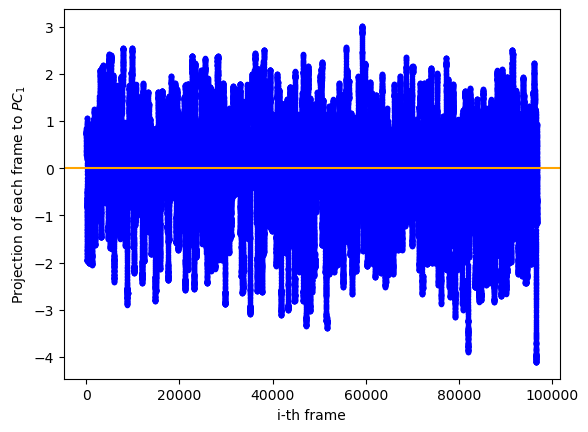

In [ ]:
## this gives us the same thing as plotting reduced_coords[:,0] which is the reduced coord corresponding to the first PC

pos_projected_pc1 = (atom_pos_s0 - np.average(atom_pos_s0, axis=0)) @ eigvecs_s0[0, :]

plt.plot(pos_projected_pc1[::2], "b.")
plt.axhline(np.mean(pos_projected_pc1), color="orange")
plt.xlabel("i-th frame")
plt.ylabel("Projection of each frame to $PC_1$")
plt.show()

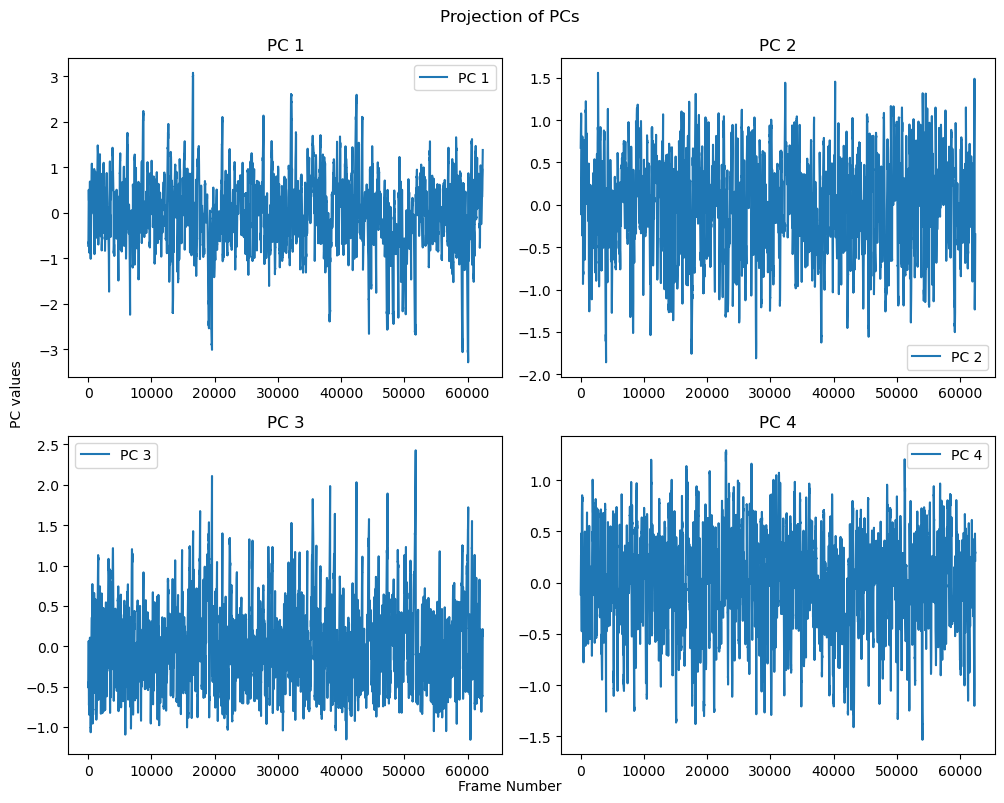

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].plot(reduced_coords_s1[:, 0], label="PC 1")
axes[0, 0].set_title("PC 1")
axes[0, 0].legend()

axes[0, 1].plot(reduced_coords_s1[:, 1], label="PC 2")
axes[0, 1].set_title("PC 2")
axes[0, 1].legend()

axes[1, 0].plot(reduced_coords_s1[:, 2], label="PC 3")
axes[1, 0].set_title("PC 3")
axes[1, 0].legend()

axes[1, 1].plot(reduced_coords_s1[:, 3], label="PC 4")
axes[1, 1].set_title("PC 4")
axes[1, 1].legend()

fig.suptitle("Projection of PCs", fontsize=12)
fig.text(
    0.5, 0.0, "Frame Number", ha="center", va="bottom"
)  # Adjust position as needed
fig.text(0.0, 0.5, "PC values", va="center", rotation="vertical")


plt.tight_layout()
plt.show()

# S1 v/s S0 PCA comparison

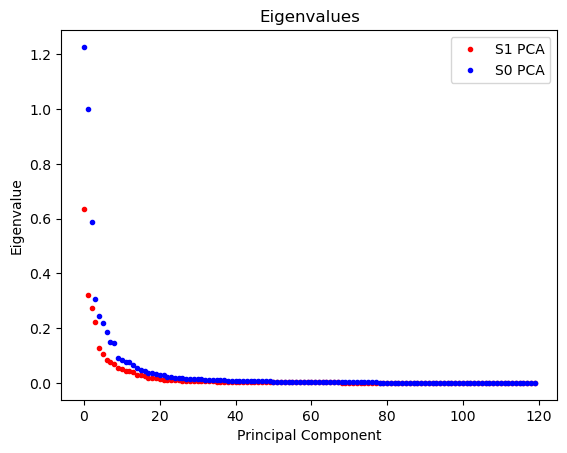

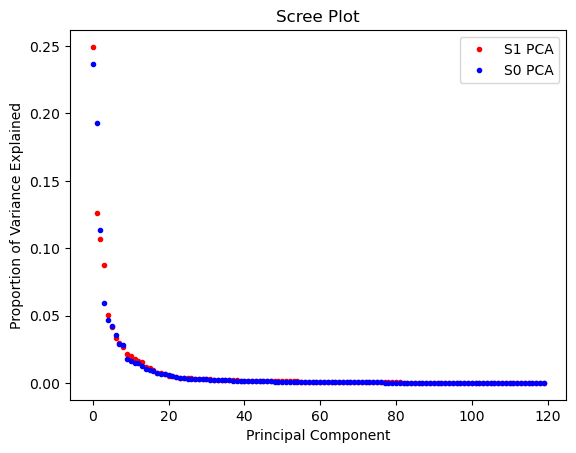

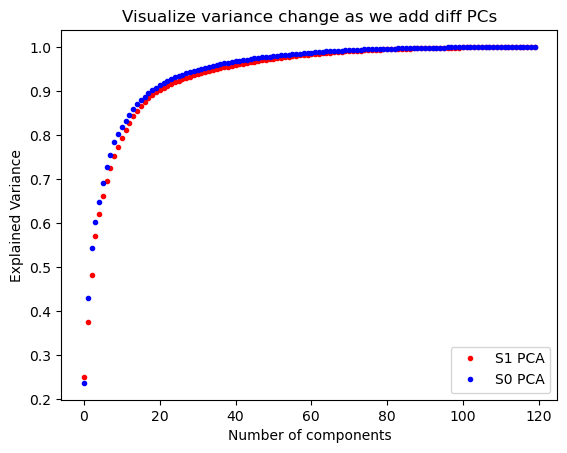

In [ ]:
plt.title("Eigenvalues")
plt.plot(eigvals_s1, "r.", label="S1 PCA")
plt.plot(eigvals_s0, "b.", label="S0 PCA")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.legend()
plt.show()

plt.title("Scree Plot")
plt.plot(expl_var_s1, "r.", label="S1 PCA")
plt.plot(expl_var_s0, "b.", label="S0 PCA")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.legend()
plt.show()

plt.title("Visualize variance change as we add diff PCs")
plt.ylabel("Explained Variance")
plt.xlabel("Number of components")
plt.plot(np.cumsum(expl_var_s1), "r.", label="S1 PCA")
plt.plot(np.cumsum(expl_var_s0), "b.", label="S0 PCA")
plt.legend()
plt.show()